# Zero-Sum Games and the Minimax Theorem

A **two-player zero-sum game** is defined by a payoff matrix $C \in \mathbb{R}^{m \times n}$: player I chooses a row strategy $p \in \Delta_m$ and player II chooses a column strategy $q \in \Delta_n$ (both from the probability simplex). Player I receives $p^\top C q$ and player II pays the same amount.

## Minimax theorem (von Neumann, 1928)

For any matrix game $C$:
$$
\min_{q \in \Delta_n} \max_{p \in \Delta_m} p^\top C q
= \max_{p \in \Delta_m} \min_{q \in \Delta_n} p^\top C q
= v^*.
$$
The common value $v^*$ is the **game value**. The pair $(p^*, q^*)$ achieving it is a **Nash equilibrium** (saddle point): neither player gains by unilaterally deviating.

## Chambolle–Pock primal-dual algorithm

The saddle-point problem $\min_p \max_q \langle q, Cp \rangle - f^*(q) + g(p)$ with $f^*(q) = \iota_{\Delta}(q)$ and $g(p) = \iota_{\Delta}(p)$ is solved by the **Chambolle–Pock** (CP) iterations:
$$
\begin{aligned}
p^{k+1} &= \Pi_{\Delta_m}\!\left(p^k - \tau C^\top q^k\right), \\
q^{k+1} &= \Pi_{\Delta_n}\!\left(q^k + \sigma C(2 p^{k+1} - p^k)\right),
\end{aligned}
$$
where $\Pi_\Delta$ denotes projection onto the simplex and $\tau \sigma \|C\|^2 < 1$ ensures convergence.

## Fictitious play

**Fictitious play** (Brown, 1951) is a simpler iterative method: each player best-responds to the empirical distribution of the opponent's past play. The time-averaged strategies converge to the Nash equilibrium for zero-sum games (but not for general games).

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, Dropdown, IntSlider

plt.rcParams['figure.dpi'] = 120

## Simplex projection and Chambolle–Pock solver

Projection onto the probability simplex $\Delta_n = \{x \geq 0 : \sum_i x_i = 1\}$ is computed in $O(n \log n)$ by sorting and thresholding.

In [2]:
def proj_simplex(v):
    """Project v onto the probability simplex."""
    n = len(v)
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.where(u > (cssv - 1) / (np.arange(n) + 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1)
    return np.maximum(v - theta, 0)


def chambolle_pock(C, n_iter=3000, tau=0.05, sigma=0.05):
    """Chambolle-Pock solver for min_p max_q p'Cq on simplices."""
    m, n = C.shape
    p = np.ones(n) / n
    q = np.ones(m) / m
    p_hist, q_hist, gap_hist = [], [], []

    for i in range(n_iter):
        p_old = p.copy()
        p = proj_simplex(p - tau * C.T @ q)
        q = proj_simplex(q + sigma * C @ (2 * p - p_old))
        gap_hist.append(np.linalg.norm(p - p_old, 1))
        if i % 50 == 0:
            p_hist.append(p.copy())
            q_hist.append(q.copy())

    return p, q, np.array(gap_hist), p_hist, q_hist


# Build test payoff matrices
n = 50
t = np.linspace(0, 1, n)
Y_g, X_g = np.meshgrid(t, t)

games = {
    'saddle':  -(X_g - 0.2)**2 + (Y_g - 0.6)**2,
    'random':  np.random.default_rng(42).standard_normal((n, n)),
    'skew':    np.sin(4 * np.pi * X_g) * np.cos(3 * np.pi * Y_g),
}
# Normalize
games = {k: v / np.abs(v).max() for k, v in games.items()}

print('Chambolle-Pock solver ready.')

Chambolle-Pock solver ready.


## Solving the saddle-point game

We solve the three matrix games and display the payoff matrix with level lines alongside the converged mixed strategies $p^*$ and $q^*$.

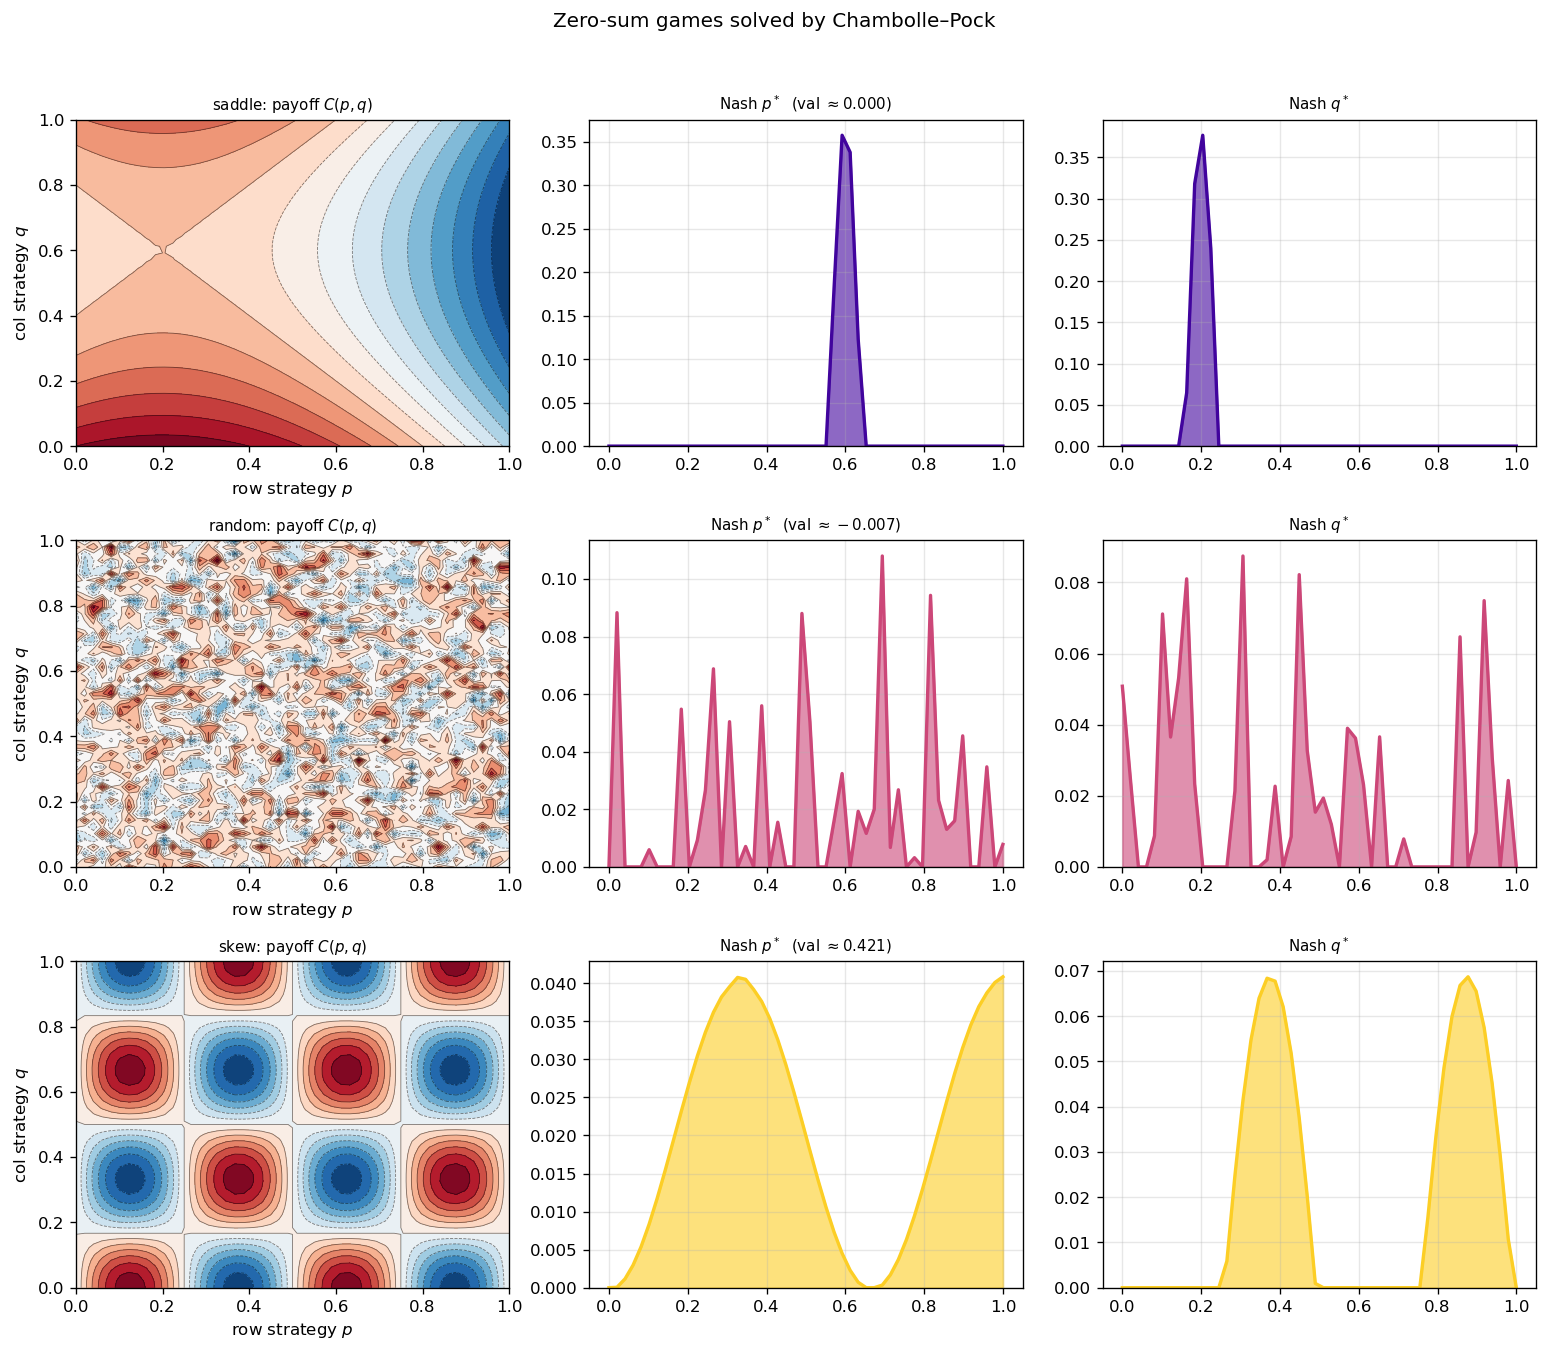

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(13, 11))
cols_row = plt.cm.plasma(np.linspace(0.1, 0.9, 3))

for row, (name, C) in enumerate(games.items()):
    p_star, q_star, gap, _, _ = chambolle_pock(C)
    v = q_star @ C @ p_star  # game value

    # Payoff matrix
    ax = axes[row, 0]
    ax.contourf(t, t, C.T, levels=15, cmap='RdBu_r')
    ax.contour(t, t, C.T, levels=15, colors='k', linewidths=0.5, alpha=0.5)
    ax.set_title(f'{name}: payoff $C(p,q)$', fontsize=9)
    ax.set_xlabel('row strategy $p$'); ax.set_ylabel('col strategy $q$')

    # Player I (row) strategy
    ax2 = axes[row, 1]
    ax2.fill_between(t, p_star, alpha=0.6, color=cols_row[row])
    ax2.plot(t, p_star, lw=2, color=cols_row[row])
    ax2.set_title(f'Nash $p^*$  (val $\\approx {v:.3f}$)', fontsize=9)
    ax2.set_ylim(0, None); ax2.grid(alpha=0.3)

    # Player II (col) strategy
    ax3 = axes[row, 2]
    ax3.fill_between(t, q_star, alpha=0.6, color=cols_row[row])
    ax3.plot(t, q_star, lw=2, color=cols_row[row])
    ax3.set_title('Nash $q^*$', fontsize=9)
    ax3.set_ylim(0, None); ax3.grid(alpha=0.3)

fig.suptitle('Zero-sum games solved by Chambolle–Pock', y=1.02)
plt.tight_layout()
plt.show()

## Convergence of the primal-dual gap

The primal-dual gap $\|p^{k+1} - p^k\|_1$ converges to 0. For Lipschitz payoffs and simplex constraints, the CP algorithm achieves $O(1/k)$ convergence in the gap.

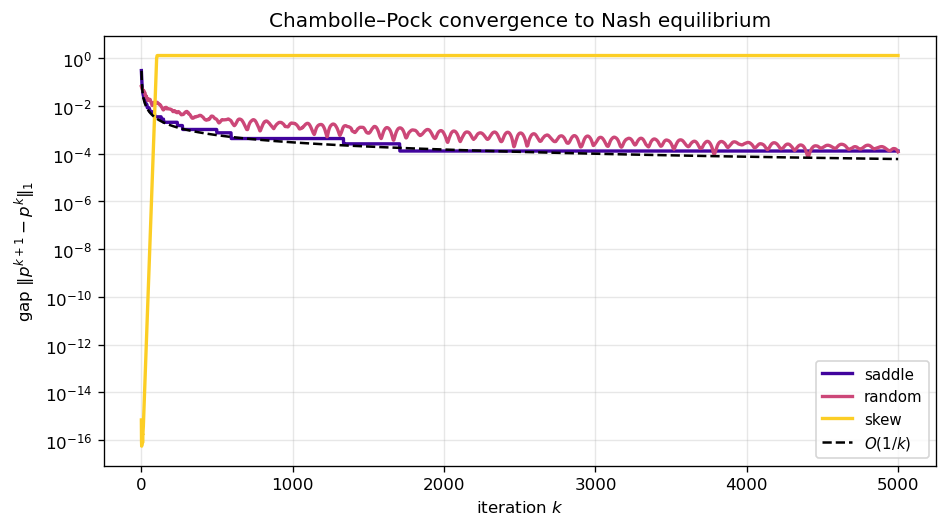

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for (name, C), col in zip(games.items(), cols_row):
    _, _, gap, _, _ = chambolle_pock(C, n_iter=5000)
    ax.semilogy(gap, lw=2, color=col, label=name)

k_range = np.arange(1, 5001)
ax.semilogy(k_range, 0.3 / k_range, 'k--', lw=1.5, label='$O(1/k)$')
ax.set_xlabel('iteration $k$'); ax.set_ylabel('gap $\\|p^{k+1}-p^k\\|_1$')
ax.set_title('Chambolle–Pock convergence to Nash equilibrium')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Fictitious play

In fictitious play, each player best-responds to the empirical time-average of the opponent. For zero-sum games, the time-average converges to the Nash equilibrium at rate $O(1/\sqrt{k})$.

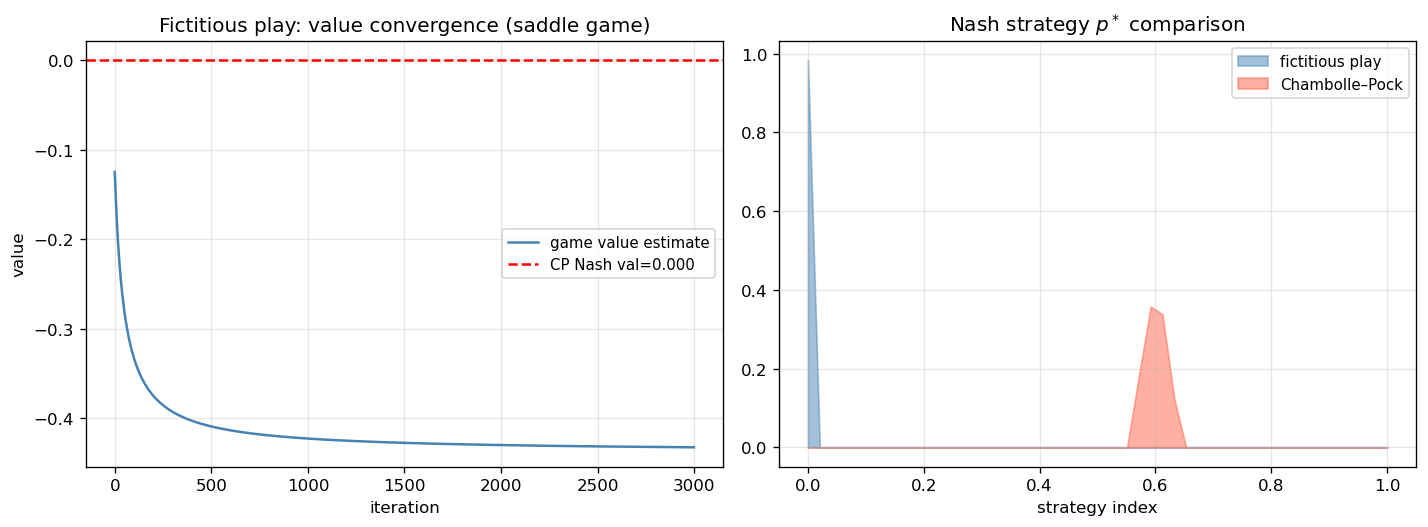

In [5]:
def fictitious_play(C, n_iter=2000):
    """Fictitious play: best-response to empirical opponent distribution."""
    m, n = C.shape
    # Initialize with uniform
    cnt_p = np.ones(n)
    cnt_q = np.ones(m)
    vals = []
    for _ in range(n_iter):
        q_avg = cnt_q / cnt_q.sum()
        p_avg = cnt_p / cnt_p.sum()
        # Best responses
        br_p = np.argmax(C.T @ q_avg)    # row player maximizes
        br_q = np.argmin(C @ p_avg)      # col player minimizes
        cnt_p[br_p] += 1
        cnt_q[br_q] += 1
        vals.append(q_avg @ C @ p_avg)
    return cnt_p / cnt_p.sum(), cnt_q / cnt_q.sum(), np.array(vals)

C_demo = games['saddle']
p_fp, q_fp, vals_fp = fictitious_play(C_demo, n_iter=3000)
p_cp, q_cp, gap_cp, _, _ = chambolle_pock(C_demo, n_iter=3000)
v_true = q_cp @ C_demo @ p_cp

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(vals_fp, lw=1.5, color='steelblue', label='game value estimate')
axes[0].axhline(v_true, color='r', lw=1.5, ls='--', label=f'CP Nash val={v_true:.3f}')
axes[0].set_xlabel('iteration'); axes[0].set_ylabel('value')
axes[0].set_title('Fictitious play: value convergence (saddle game)')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].fill_between(t, p_fp, alpha=0.5, color='steelblue', label='fictitious play')
axes[1].fill_between(t, p_cp, alpha=0.5, color='tomato', label='Chambolle–Pock')
axes[1].set_title('Nash strategy $p^*$ comparison')
axes[1].set_xlabel('strategy index'); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Interactive: explore different games

Select a payoff structure and run the solver to see the Nash equilibrium strategies.

In [6]:
def show_game(game='saddle', n_iter=2000):
    C = games[game]
    p_star, q_star, gap, _, _ = chambolle_pock(C, n_iter=n_iter)
    v = q_star @ C @ p_star

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].contourf(t, t, C.T, levels=20, cmap='RdBu_r')
    axes[0].contour(t, t, C.T, levels=10, colors='k', linewidths=0.5)
    axes[0].set_title(f'{game} payoff'); axes[0].set_aspect('equal')

    axes[1].fill_between(t, p_star, alpha=0.7, color='royalblue')
    axes[1].set_title(f'Player I strategy $p^*$ (val={v:.3f})')
    axes[1].grid(alpha=0.3)

    axes[2].fill_between(t, q_star, alpha=0.7, color='tomato')
    axes[2].set_title('Player II strategy $q^*$')
    axes[2].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

interact(show_game,
         game=Dropdown(options=list(games.keys()), description='game'),
         n_iter=IntSlider(value=2000, min=200, max=8000, step=200, description='iters'));

interactive(children=(Dropdown(description='game', options=('saddle', 'random', 'skew'), value='saddle'), IntS…

## Bibliographical resources

- von Neumann, J. (1928). Zur Theorie der Gesellschaftsspiele. *Mathematische Annalen*, 100(1), 295–320.
- Nash, J. (1951). Non-cooperative games. *Annals of Mathematics*, 54(2), 286–295.
- Brown, G. W. (1951). Iterative solution of games by fictitious play. In *Activity Analysis of Production and Allocation* (pp. 374–376). Wiley.
- Chambolle, A. and Pock, T. (2011). A first-order primal-dual algorithm for convex problems with applications to imaging. *Journal of Mathematical Imaging and Vision*, 40(1), 120–145.
- Nisan, N., Roughgarden, T., Tardos, E. and Vazirani, V. V. (Eds.) (2007). *Algorithmic Game Theory*. Cambridge University Press.